# Decision trees

A decision tree splits the feature space into rectangles with a sequence of yes/no questions ("is the price difference below 0.05?") and predicts the majority class (or the mean value) in each rectangle. Trees are easy to explain and handle mixed variable types and interactions automatically, but a fully grown tree memorizes the training data.

This notebook covers:

1. how a split is chosen: **impurity measures**;
2. what a tree does to the feature space, on a small 2D example;
3. **overfitting and cost-complexity pruning**, with the tree size chosen by cross-validation (orange juice purchases);
4. **classification vs regression trees** for the same question (fuel efficiency of cars).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

plt.rcParams["figure.dpi"] = 100

## 1. Measuring impurity

At each step the tree looks for the split that makes the two resulting groups as **pure** as possible. For a node where a fraction $p$ of the observations belongs to class 1, the three classic impurity measures are:

- **misclassification error**: $E = 1 - \max(p, 1 - p)$;
- **Gini index**: $G = 2p(1 - p)$;
- **entropy**: $D = -p \log p - (1 - p)\log(1 - p)$.

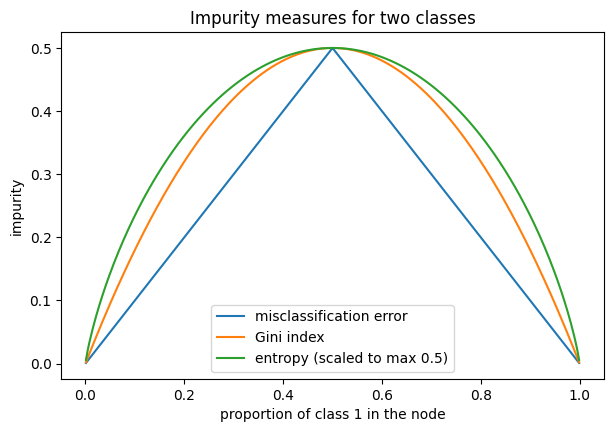

In [2]:
p = np.linspace(0.001, 0.999, 300)
error = 1 - np.maximum(p, 1 - p)
gini = 2 * p * (1 - p)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p, error, label="misclassification error")
ax.plot(p, gini, label="Gini index")
ax.plot(p, entropy / 2, label="entropy (scaled to max 0.5)")
ax.set(xlabel="proportion of class 1 in the node", ylabel="impurity", title="Impurity measures for two classes")
ax.legend()
plt.show()

All three are zero for a pure node and maximal at $p = 0.5$. Gini and entropy are **strictly concave**, while the misclassification error is piecewise linear. This matters when growing a tree: a split that makes both children purer can leave the misclassification error unchanged (if the majority class stays the same on both sides), while Gini and entropy always reward it. That is why trees are grown with Gini or entropy, and the error rate is used only to evaluate them.

## 2. A tree on a 2D example

To see what a tree does to the feature space, we classify 32 cars as having a manual or automatic transmission from just two features: fuel efficiency (mpg) and horsepower.

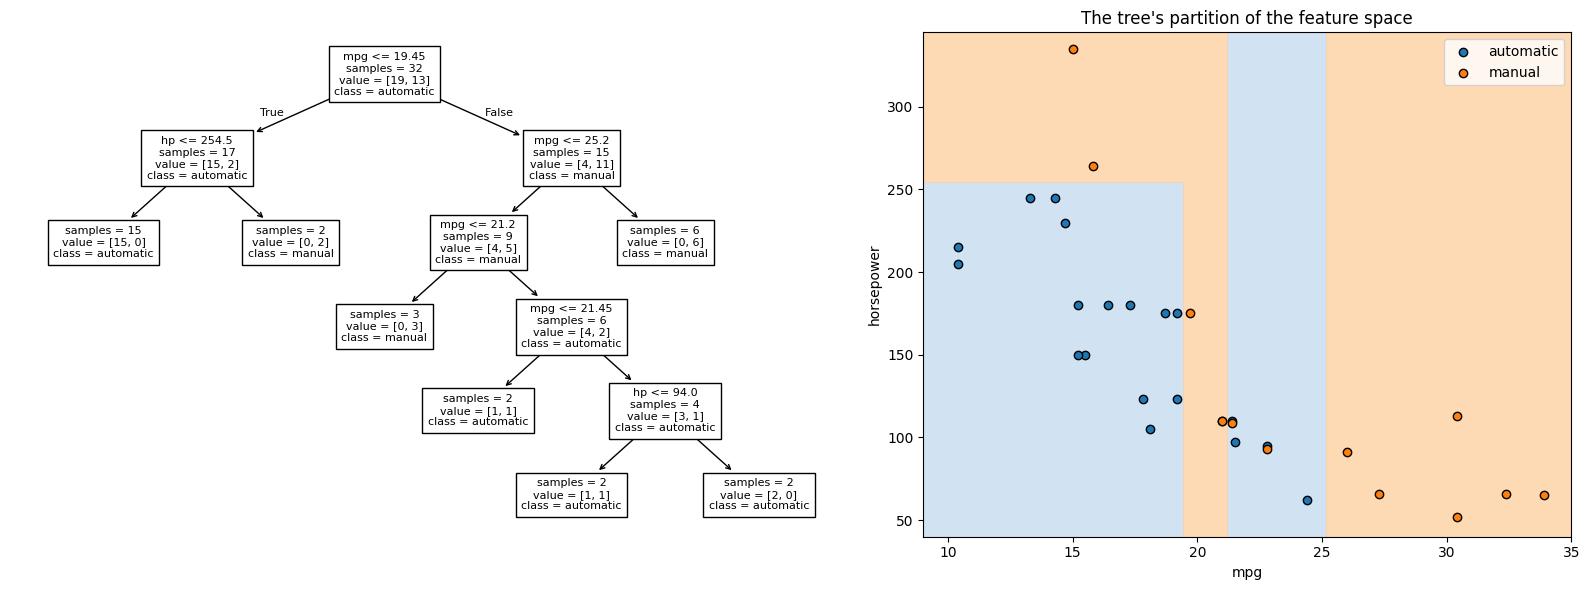

In [3]:
cars = pd.read_csv("data/mtcars.csv")
X2, y2 = cars[["mpg", "hp"]], cars["am"].map({0: "automatic", 1: "manual"})
small_tree = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=2, random_state=0).fit(X2, y2)

xx, yy = np.meshgrid(np.linspace(9, 35, 400), np.linspace(40, 345, 400))
grid = pd.DataFrame({"mpg": xx.ravel(), "hp": yy.ravel()})
zz = (small_tree.predict(grid) == "manual").reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.3, 1]})
plot_tree(small_tree, feature_names=["mpg", "hp"], class_names=small_tree.classes_, filled=False, impurity=False, ax=ax1, fontsize=8)
ax2.contourf(xx, yy, zz, cmap=ListedColormap(["#c6dbef", "#fdd0a2"]), alpha=0.8)
for label, color in [("automatic", "tab:blue"), ("manual", "tab:orange")]:
    mask = y2 == label
    ax2.scatter(X2.loc[mask, "mpg"], X2.loc[mask, "hp"], color=color, edgecolor="black", label=label)
ax2.set(xlabel="mpg", ylabel="horsepower", title="The tree's partition of the feature space")
ax2.legend()
fig.tight_layout()
plt.show()

Every split is a horizontal or vertical line, so the tree carves the plane into rectangles, each with its own prediction. With only 32 cars and leaves of two observations, some rectangles exist to capture just one or two points: a first sign of overfitting.

## 3. Overfitting and pruning: orange juice purchases

The dataset records 1,070 purchases of orange juice of two brands, Citrus Hill (CH) and Minute Maid (MM), together with prices, discounts, promotions, the store, and `LoyalCH`, a measure of the customer's past loyalty to Citrus Hill. Can we predict which brand a customer will buy?

The store is stored as a numeric code. A tree would treat the code as an ordered quantity, so we one-hot encode it.

In [4]:
oj = pd.read_csv("data/orange_juice.csv")
oj = pd.get_dummies(oj.drop(columns=["StoreID", "Store7"]), columns=["STORE"], prefix="store", dtype=int)
X, y = oj.drop(columns="Purchase"), oj["Purchase"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=800, random_state=1, stratify=y)
print(f"training: {len(X_train)}, test: {len(X_test)}, share of CH purchases: {(y == 'CH').mean():.1%}")

training: 800, test: 270, share of CH purchases: 61.0%


First, a tree grown until every leaf is pure:

In [5]:
full_tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
pd.Series({
    "leaves": full_tree.get_n_leaves(),
    "depth": full_tree.get_depth(),
    "training error": round(1 - full_tree.score(X_train, y_train), 3),
    "test error": round(1 - full_tree.score(X_test, y_test), 3),
})

leaves            173.000
depth              16.000
training error      0.012
test error          0.222
dtype: float64

With 173 leaves the tree classifies almost every training purchase correctly (1.2% error), but on new purchases the error jumps to 22%. The tree has memorized noise.

**Cost-complexity pruning** grows the full tree and then cuts it back. For a penalty $\alpha \ge 0$ it keeps the subtree $T$ that minimizes

$$\text{training error}(T) + \alpha \cdot |T|,$$

where $|T|$ is the number of leaves. As $\alpha$ grows, the optimal tree gets smaller. We choose $\alpha$ by 10-fold cross-validation on the training set.

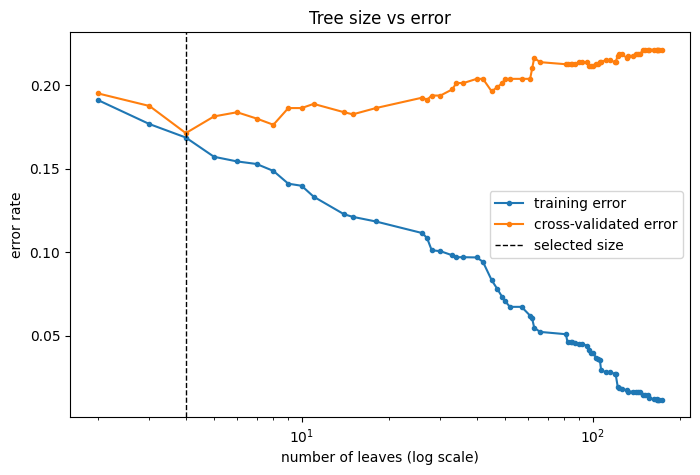

In [6]:
alphas = full_tree.cost_complexity_pruning_path(X_train, y_train).ccp_alphas[:-1]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
search = GridSearchCV(DecisionTreeClassifier(random_state=0), {"ccp_alpha": alphas}, cv=cv, return_train_score=True)
search.fit(X_train, y_train)

results = pd.DataFrame(search.cv_results_)
results["leaves"] = [DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X_train, y_train).get_n_leaves() for a in alphas]
by_size = results.groupby("leaves")[["mean_train_score", "mean_test_score"]].max()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(by_size.index, 1 - by_size["mean_train_score"], "o-", ms=3, label="training error")
ax.plot(by_size.index, 1 - by_size["mean_test_score"], "o-", ms=3, label="cross-validated error")
ax.axvline(search.best_estimator_.get_n_leaves(), color="black", ls="--", lw=1, label="selected size")
ax.set(xscale="log", xlabel="number of leaves (log scale)", ylabel="error rate", title="Tree size vs error")
ax.legend()
plt.show()

The training error keeps falling as the tree grows. The cross-validated error is lowest for very small trees and then increases: beyond a handful of leaves, extra splits only fit noise.

In [7]:
pruned = search.best_estimator_
pd.DataFrame({
    "full tree": [full_tree.get_n_leaves(), 1 - full_tree.score(X_train, y_train), np.nan, 1 - full_tree.score(X_test, y_test)],
    "pruned tree": [pruned.get_n_leaves(), 1 - pruned.score(X_train, y_train), 1 - search.best_score_, 1 - pruned.score(X_test, y_test)],
}, index=["leaves", "training error", "CV error", "test error"]).round(3)

,full tree,pruned tree
leaves,173.000,4.000
training error,0.012,0.169
CV error,NaN,0.171
test error,0.222,0.181


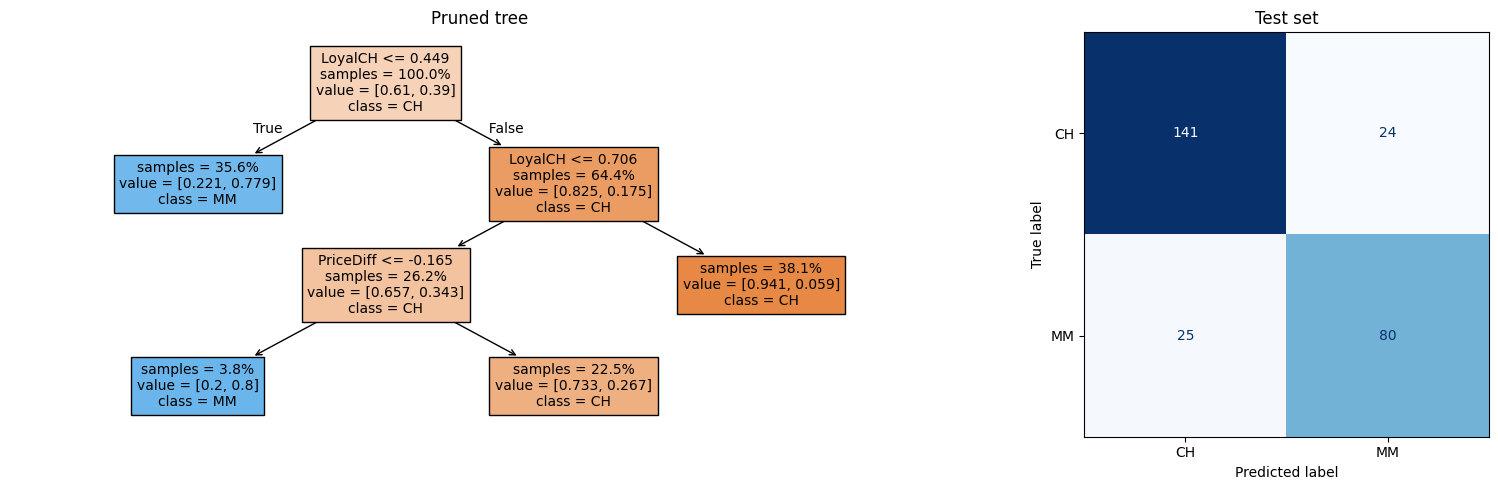

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.6, 1]})
plot_tree(pruned, feature_names=X.columns, class_names=pruned.classes_, filled=True, impurity=False, proportion=True, ax=ax1, fontsize=10)
ax1.set_title("Pruned tree")
ConfusionMatrixDisplay.from_estimator(pruned, X_test, y_test, cmap="Blues", ax=ax2, colorbar=False)
ax2.set_title("Test set")
fig.tight_layout()
plt.show()

The pruned tree has only **4 leaves**, yet it is *more* accurate on new data than the 173-leaf tree (18% vs 22% test error). It is also easy to read:

- **customer loyalty** (`LoyalCH`) is by far the most important variable: customers with high loyalty (above 0.71) buy Citrus Hill 94% of the time, customers with low loyalty (below 0.45) buy Minute Maid 78% of the time;
- for customers in between, the **price** decides: when Minute Maid is clearly cheaper than Citrus Hill (`PriceDiff` below −0.17), they switch to Minute Maid.

A marketing team can act on this directly: price promotions only matter for the undecided middle group.

## 4. Classification tree or regression tree?

Back to the cars: we want to know whether a car is fuel efficient (mpg above the median). We can either

- fit a **classification tree** directly on the binary label, or
- fit a **regression tree** on mpg itself and then threshold its prediction at the median.

Both trees are pruned by cross-validation and compared on the same test set.

In [9]:
auto = pd.read_csv("data/auto.csv")
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]
X_a, mpg = auto[features], auto["mpg"]
X_tr, X_te, mpg_tr, mpg_te = train_test_split(X_a, mpg, test_size=0.25, random_state=0, stratify=mpg > mpg.median())
threshold = mpg_tr.median()
high_tr, high_te = (mpg_tr > threshold).astype(int), (mpg_te > threshold).astype(int)

def pruned_tree(estimator, X, target):
    alphas = estimator.fit(X, target).cost_complexity_pruning_path(X, target).ccp_alphas[:-1]
    return GridSearchCV(estimator, {"ccp_alpha": alphas}, cv=10).fit(X, target).best_estimator_

clf = pruned_tree(DecisionTreeClassifier(random_state=0), X_tr, high_tr)
reg = pruned_tree(DecisionTreeRegressor(random_state=0), X_tr, mpg_tr)

pd.DataFrame({
    "classification tree": [clf.get_n_leaves(), np.mean(clf.predict(X_te) != high_te)],
    "regression tree + threshold": [reg.get_n_leaves(), np.mean((reg.predict(X_te) > threshold).astype(int) != high_te)],
}, index=["leaves", "test error"]).round(3)

,classification tree,regression tree + threshold
leaves,29.000,10.000
test error,0.102,0.143


Regression tree: test R^2 for mpg = 0.738


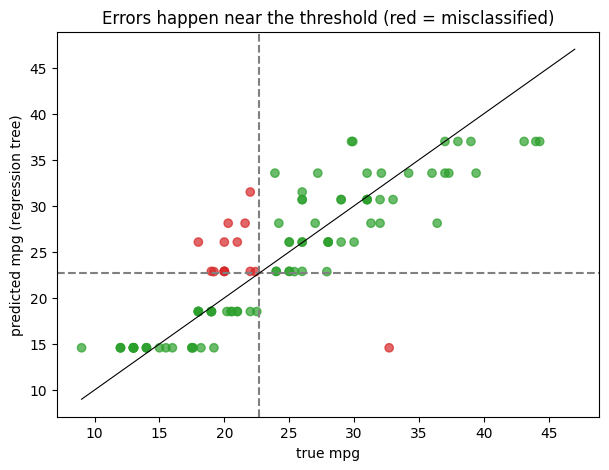

In [10]:
print(f"Regression tree: test R^2 for mpg = {reg.score(X_te, mpg_te):.3f}")
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mpg_te, reg.predict(X_te), c=np.where((reg.predict(X_te) > threshold) == (mpg_te > threshold), "tab:green", "tab:red"), alpha=0.7)
ax.axvline(threshold, color="grey", ls="--")
ax.axhline(threshold, color="grey", ls="--")
ax.plot([9, 47], [9, 47], color="black", lw=0.8)
ax.set(xlabel="true mpg", ylabel="predicted mpg (regression tree)", title="Errors happen near the threshold (red = misclassified)")
plt.show()

The classification tree makes fewer errors on the test set. The regression tree explains mpg reasonably well ($R^2 \approx 0.74$), but it optimizes something else: it tries to predict mpg accurately over the whole range, from 10 to 45. The classification question only depends on what happens **near the median**, and that is exactly where the misclassified cars are. With its few leaves, the regression tree predicts the same value for many cars on both sides of the threshold.

**Takeaway:** fit the model to the question you need to answer. A classifier trained on the decision of interest usually beats a regression model thresholded after the fact, because its splits concentrate where the classes meet.

## Summary

- Trees choose splits with **Gini or entropy**; the misclassification rate is too coarse to grow them.
- A fully grown tree **overfits** badly. Cost-complexity pruning with cross-validation finds a much smaller tree that generalizes better.
- Small pruned trees are **interpretable rules** that can be acted upon (loyalty first, then price).
- Fit the model to the decision you care about: a classification tree beats a thresholded regression tree for a classification question.
- Trees remain **unstable**: a slightly different sample can produce a very different tree. The next notebook fixes this by averaging many trees.